# Euroleague 2025-26 Data Analysis

## Introduction
Analysis of Euroleague 2025-26 season statistics.
Data source from basketball-reference.com

### Questions we answer:
- Which teams have the best offence and defense?
- Is there a relationship between 3-pointers and wins? 
- Which players are the most efficient?
- Which players are underrated?
- Which teams are most dependent on one player? 
- Budget vs. performance: which teams get the most out of their money? 

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
from adjustText import adjust_text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Connect to database
db_path = os.path.join(os.path.dirname(os.getcwd()), "euroleague.db")
conn = sqlite3.connect(db_path)

# Load data
standings = pd.read_sql('SELECT * FROM standings', conn)
team_stats = pd.read_sql('SELECT * FROM team_stats_pergame', conn)
player_stats = pd.read_sql('SELECT * FROM player_stats', conn)
team_payroll = pd.read_sql('SELECT * FROM team_payroll', conn)

print(f'Standings: {standings.shape}')
print(f'Team Stats: {team_stats.shape}')
print(f'Player Stats: {player_stats.shape}')
print(f'Team Payroll: {team_payroll.shape}')

Standings: (20, 7)
Team Stats: (20, 24)
Player Stats: (341, 26)
Team Payroll: (20, 2)


In [2]:
# Rename columns for merging
team_payroll = team_payroll.rename(columns={"team": "Team"})
team_stats = team_stats.rename(columns={"Club": "Team"})

# Merge all team-level dataframes
df_teams = standings.merge(team_stats, on="Team").merge(team_payroll, on="Team")
df_teams = df_teams.drop(columns=["PPG"])

# Calculate player stats
player_stats['missed_FG'] = player_stats['FGA'] - player_stats['FG']
player_stats['missed_FT'] = player_stats['FTA'] - player_stats['FT']
player_stats['PIR'] = (
    (player_stats['PTS'] + player_stats['TRB'] + player_stats['AST'] +
     player_stats['STL'] + player_stats['BLK']
     - player_stats['missed_FG'] - player_stats['missed_FT']
     - player_stats['TOV']) / player_stats['G']
)

print(f'Teams dataframe: {df_teams.shape}')
print(f'Player stats ready!')

Teams dataframe: (20, 30)
Player stats ready!


### Question 1: Which teams have the best offense and defense?

Comparing teams based on points scored per game (PS/G) and points allowed per game (PA/G).
Teams in the bottom-right quadrant score a lot while conceding few points — the best overall performers.

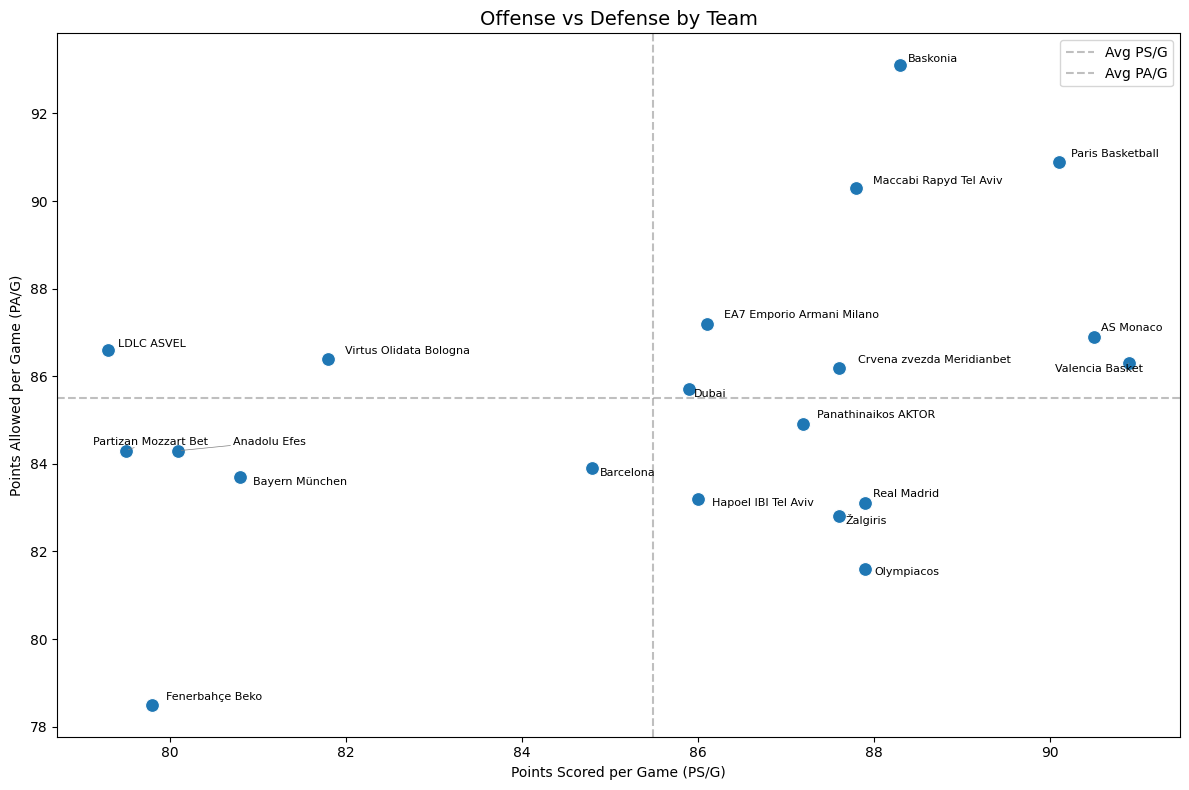

In [3]:
# Question 1: Which teams have the best offense and defense?
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_teams, x="PS/G", y="PA/G", s=100, ax=ax)
texts = []
for _, row in df_teams.iterrows():
    texts.append(ax.text(row["PS/G"], row["PA/G"], row["Team"], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.axvline(df_teams["PS/G"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg PS/G")
ax.axhline(df_teams["PA/G"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg PA/G")
ax.set_title("Offense vs Defense by Team", fontsize=14)
ax.set_xlabel("Points Scored per Game (PS/G)")
ax.set_ylabel("Points Allowed per Game (PA/G)")
ax.legend()
plt.tight_layout()
plt.show()

### Question 2: Is there a relationship between 3-point shooting and wins?

Analyzing whether teams that shoot better from 3-point range tend to win more games.
Key finding: Žalgiris has the best 3P% (39.8%) but is not the top team — 3-point shooting alone does not explain wins.

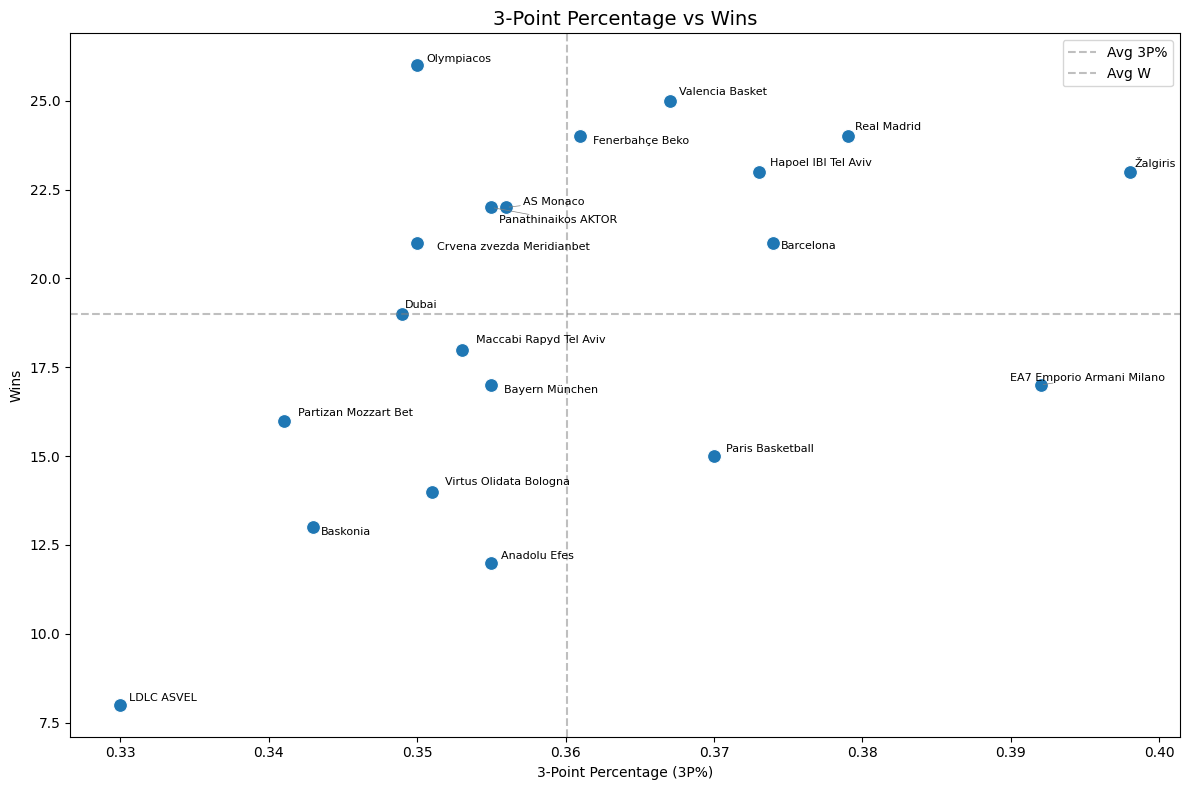

In [4]:
# Question 2: Is there a relationship between 3-point shooting and wins?
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_teams, x="3P%", y="W", s=100, ax=ax)
texts = []
for _, row in df_teams.iterrows():
    texts.append(ax.text(row["3P%"], row["W"], row["Team"], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.axvline(df_teams["3P%"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg 3P%")
ax.axhline(df_teams["W"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg W")
ax.set_title("3-Point Percentage vs Wins", fontsize=14)
ax.set_xlabel("3-Point Percentage (3P%)")
ax.set_ylabel("Wins")
ax.legend()
plt.tight_layout()
plt.show()

### Question 3: How can we group teams based on their playing style?

Using K-Means clustering on key stats (PS/G, PA/G, 3P%, AST, STL, BLK, TOV) to identify 4 distinct playing styles:
- **Balanced Elite**: strong on both ends
- **Offensive**: high scoring, weaker defense
- **Defensive**: low pace, strong defense
- **3-Point Oriented**: heavily reliant on the 3-point shot

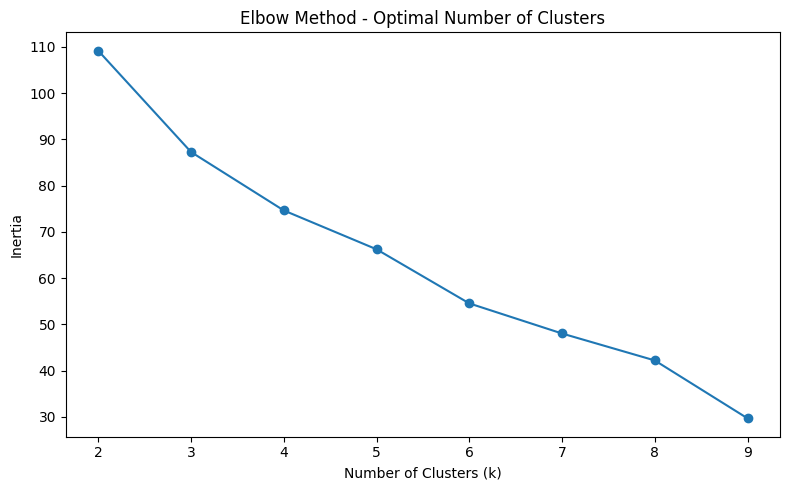

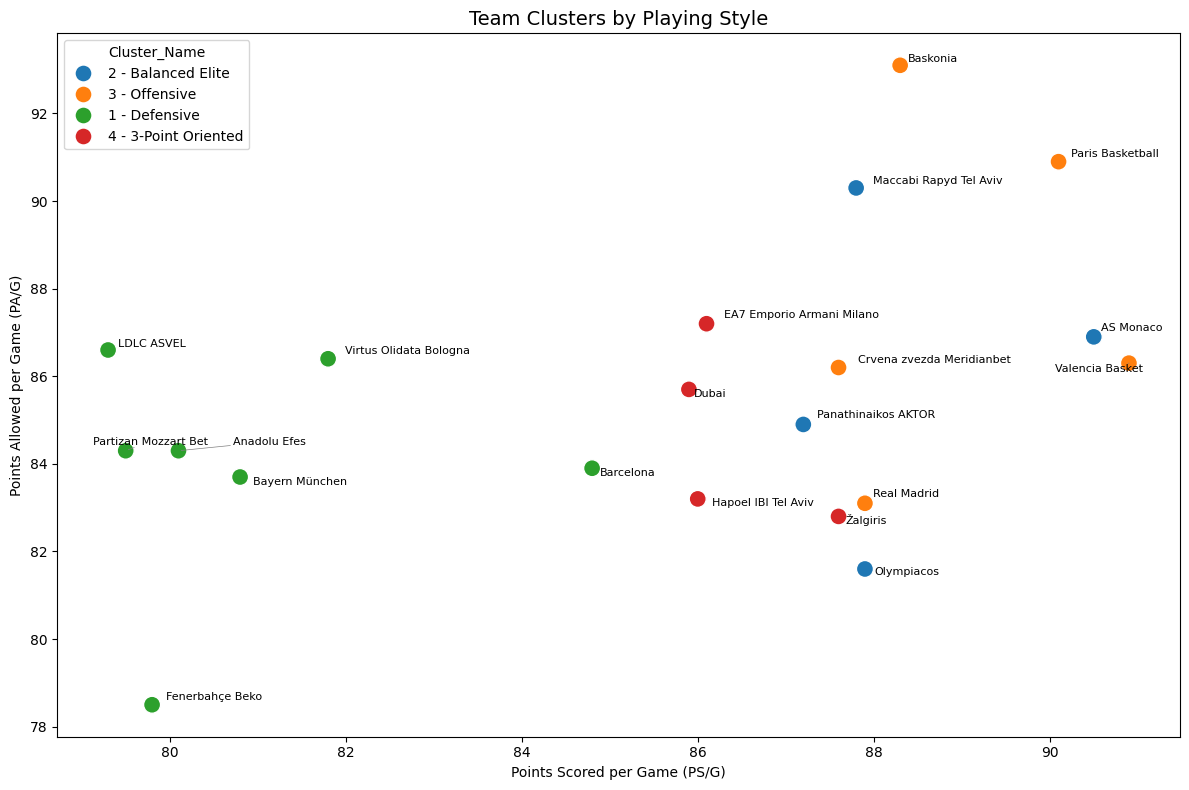

In [5]:
# Question 3: Team clustering based on playing style
features = ['PS/G', 'PA/G', '3P%', 'AST', 'STL', 'BLK', 'TOV']
X = df_teams[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertia, marker='o')
ax.set_title('Elbow Method - Optimal Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()

# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_teams['Cluster'] = kmeans.fit_predict(X_scaled)
cluster_names = {
    0: '2 - Balanced Elite',
    1: '1 - Defensive',
    2: '3 - Offensive',
    3: '4 - 3-Point Oriented'
}
df_teams['Cluster_Name'] = df_teams['Cluster'].map(cluster_names)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_teams, x='PS/G', y='PA/G', hue='Cluster_Name', s=150, ax=ax)
texts = []
for _, row in df_teams.iterrows():
    texts.append(ax.text(row['PS/G'], row['PA/G'], row['Team'], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
ax.set_title('Team Clusters by Playing Style', fontsize=14)
ax.set_xlabel('Points Scored per Game (PS/G)')
ax.set_ylabel('Points Allowed per Game (PA/G)')
plt.tight_layout()
plt.show()

### Question 4: Which players are the most efficient?

Using a PIR-based formula (Points + Rebounds + Assists + Steals + Blocks - Missed FGs - Missed FTs - Turnovers) per game.
Minimum 200 minutes played to ensure a reliable sample size.

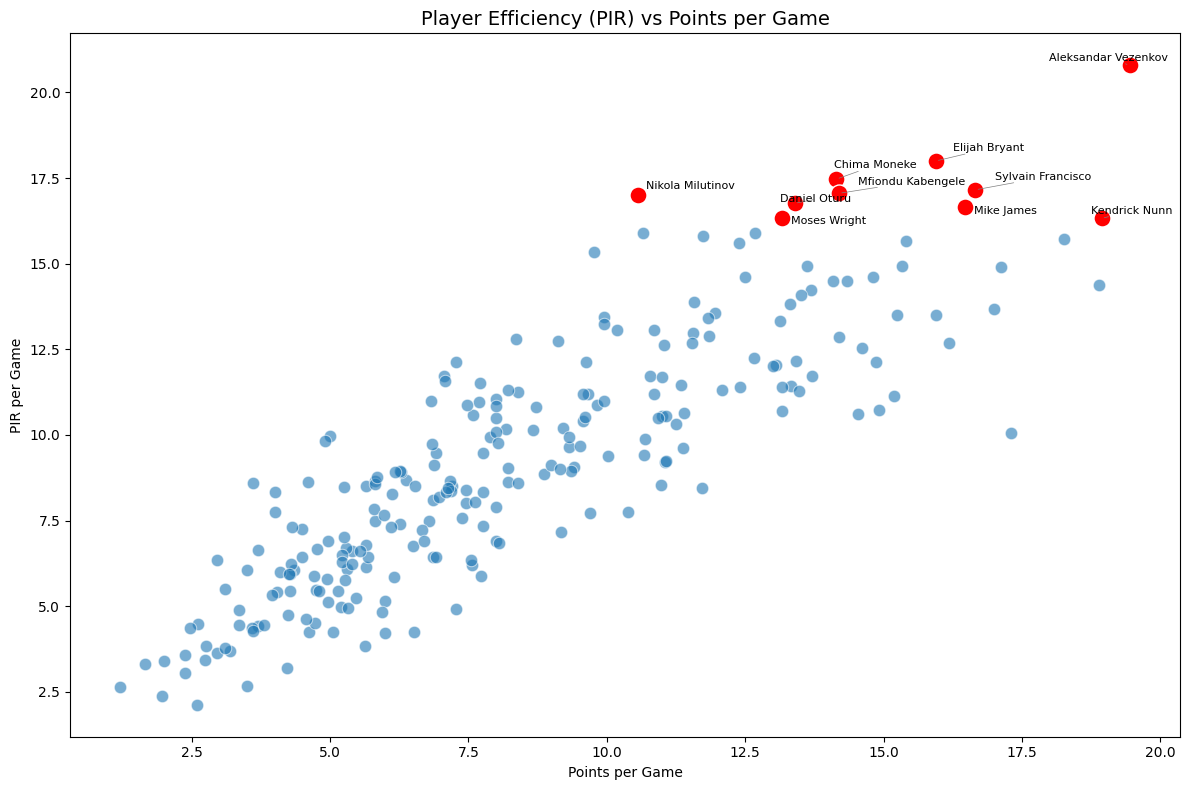

In [6]:
# Question 4: Which players are the most efficient?
df_players = player_stats[player_stats['MP'] > 200].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_players, x=df_players['PTS']/df_players['G'],
                y='PIR', s=80, alpha=0.6, ax=ax)
top10 = df_players.nlargest(10, 'PIR')
sns.scatterplot(data=top10, x=top10['PTS']/top10['G'],
                y='PIR', s=150, color='red', ax=ax)
texts = []
for _, row in top10.iterrows():
    texts.append(ax.text(row['PTS']/row['G'], row['PIR'], row['Player'], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
ax.set_title('Player Efficiency (PIR) vs Points per Game', fontsize=14)
ax.set_xlabel('Points per Game')
ax.set_ylabel('PIR per Game')
plt.tight_layout()
plt.show()

### Question 5: Which players are underrated?

Identifying players who contribute significantly without being top scorers.
Underrated = high Non-Scoring Contribution per minute (rebounds, assists, steals, blocks) + low Points per minute.
Thresholds: PTS/min < 0.35 and Non-Scoring/min > 0.30

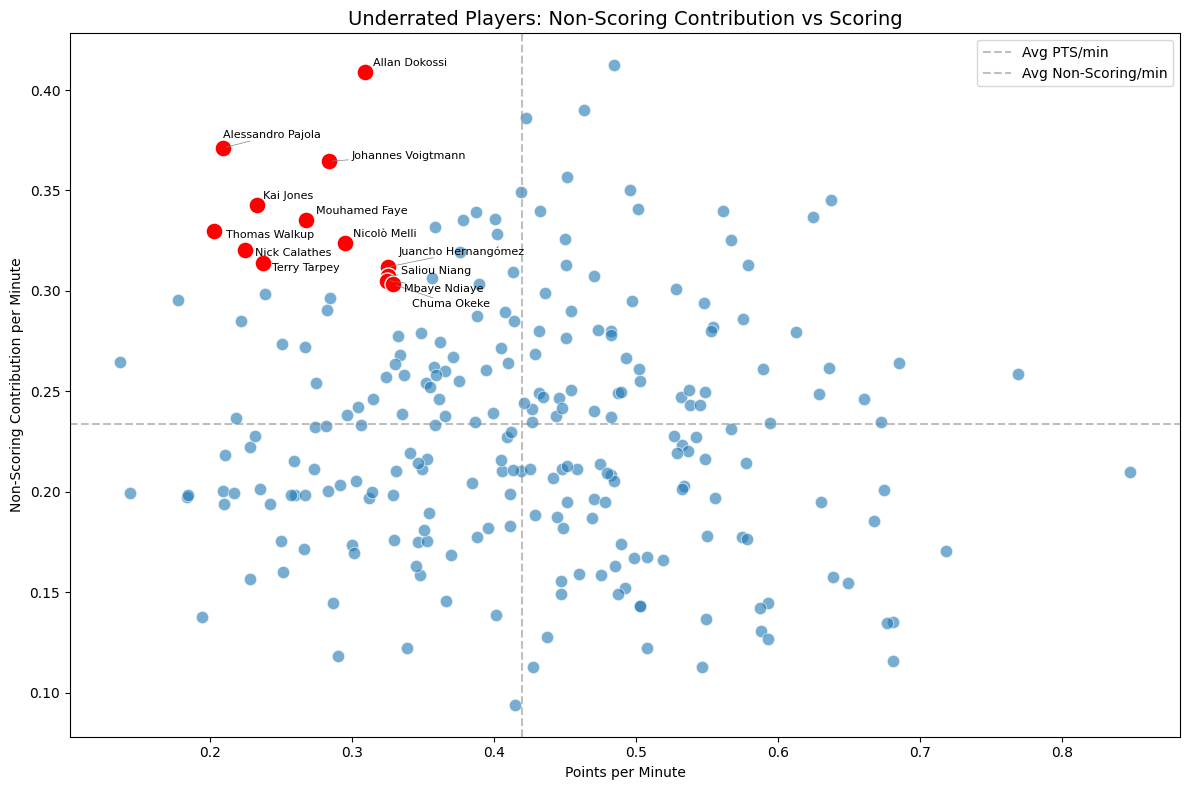

In [7]:
# Question 5: Which players are underrated?
df_players['PTS_per_min'] = df_players['PTS'] / df_players['MP']
df_players['Non_Scoring_per_min'] = (
    df_players['TRB'] + df_players['AST'] +
    df_players['STL'] + df_players['BLK'] -
    df_players['TOV']) / df_players['MP']

underrated = df_players[
    (df_players['PTS_per_min'] < 0.35) &
    (df_players['Non_Scoring_per_min'] > 0.30)
].sort_values('Non_Scoring_per_min', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_players, x='PTS_per_min', y='Non_Scoring_per_min',
                s=80, alpha=0.6, ax=ax)
sns.scatterplot(data=underrated, x='PTS_per_min', y='Non_Scoring_per_min',
                s=150, color='red', ax=ax)
texts = []
for _, row in underrated.iterrows():
    texts.append(ax.text(row['PTS_per_min'], row['Non_Scoring_per_min'],
                         row['Player'], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
ax.axvline(df_players['PTS_per_min'].mean(), color='gray', linestyle='--', alpha=0.5, label='Avg PTS/min')
ax.axhline(df_players['Non_Scoring_per_min'].mean(), color='gray', linestyle='--', alpha=0.5, label='Avg Non-Scoring/min')
ax.set_title('Underrated Players: Non-Scoring Contribution vs Scoring', fontsize=14)
ax.set_xlabel('Points per Minute')
ax.set_ylabel('Non-Scoring Contribution per Minute')
ax.legend()
plt.tight_layout()
plt.show()

### Question 6: Which players perform above expectations for their role?

Focusing on players with limited minutes (100 < MP < 448) who show high PIR per minute.
These are players who maximize their impact despite not being starters.

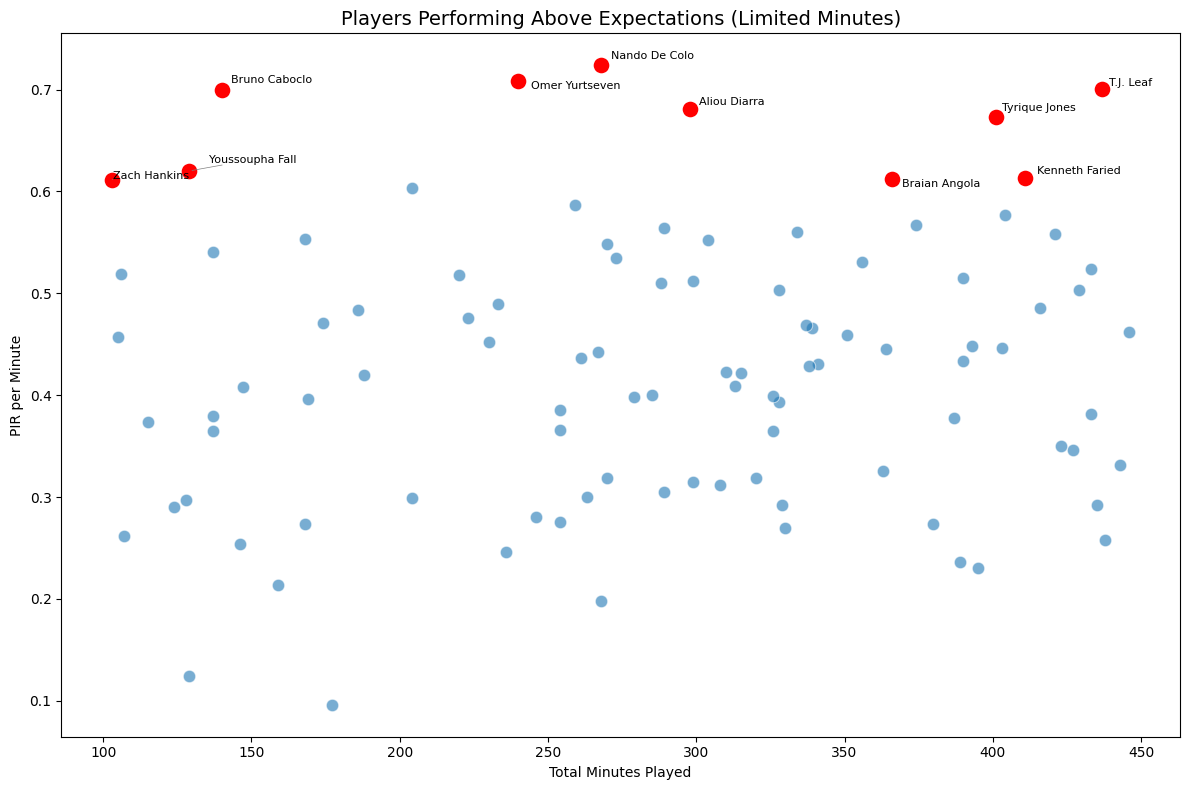

In [8]:
# Question 6: Which players perform above expectations for their role?
df_limited = player_stats[
    (player_stats['MP'] > 100) &
    (player_stats['MP'] < 448)
].copy()

df_limited['PIR'] = (df_limited['PTS'] + df_limited['TRB'] + df_limited['AST'] +
                     df_limited['STL'] + df_limited['BLK'] -
                     (df_limited['FGA'] - df_limited['FG']) -
                     (df_limited['FTA'] - df_limited['FT']) -
                     df_limited['TOV'])
df_limited['PIR_per_min'] = df_limited['PIR'] / df_limited['MP']
df_limited = df_limited.sort_values('MP', ascending=False).drop_duplicates(subset='Player', keep='first')

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_limited, x='MP', y='PIR_per_min', s=80, alpha=0.6, ax=ax)
top10_limited = df_limited.nlargest(10, 'PIR_per_min')
sns.scatterplot(data=top10_limited, x='MP', y='PIR_per_min', s=150, color='red', ax=ax)
texts = []
for _, row in top10_limited.iterrows():
    texts.append(ax.text(row['MP'], row['PIR_per_min'], row['Player'], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
ax.set_title('Players Performing Above Expectations (Limited Minutes)', fontsize=14)
ax.set_xlabel('Total Minutes Played')
ax.set_ylabel('PIR per Minute')
plt.tight_layout()
plt.show()

### Question 7: Which teams depend the most on one player?

Measuring each team's top scorer as a percentage of total team points.
High dependency can be a risk — if the top scorer is injured, the team may struggle.

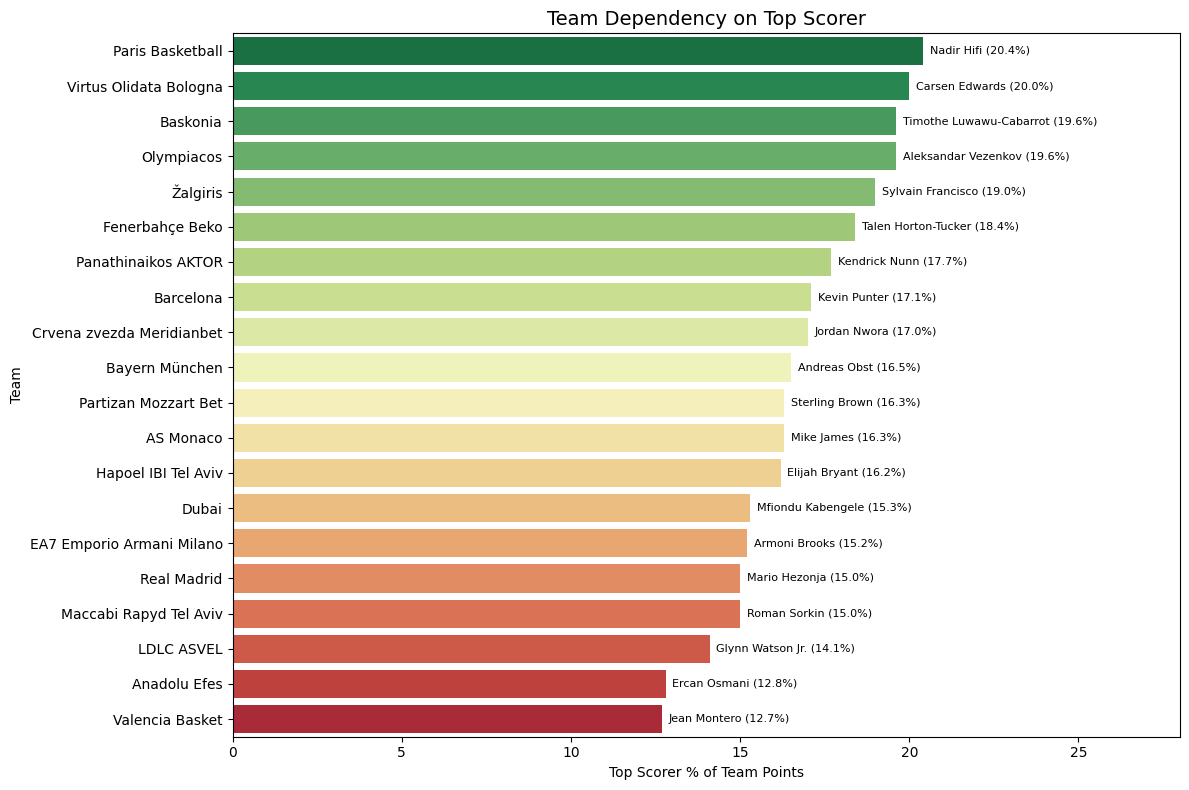

In [9]:
# Question 7: Which teams depend the most on one player?
team_totals = player_stats.groupby('Team')['PTS'].sum().reset_index()
team_totals.columns = ['Team', 'Team_PTS']
top_scorers = player_stats.loc[player_stats.groupby('Team')['PTS'].idxmax()][['Team', 'Player', 'PTS']]
top_scorers.columns = ['Team', 'Top_Scorer', 'Top_Scorer_PTS']
dependency = top_scorers.merge(team_totals, on='Team')
dependency['Dependency_Pct'] = round(dependency['Top_Scorer_PTS'] * 100 / dependency['Team_PTS'], 1)
dependency = dependency.sort_values('Dependency_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=dependency, x='Dependency_Pct', y='Team', palette='RdYlGn_r', ax=ax)
for i, row in dependency.reset_index().iterrows():
    ax.text(row['Dependency_Pct'] + 0.2, i,
            f"{row['Top_Scorer']} ({row['Dependency_Pct']}%)",
            fontsize=8, va='center')
ax.set_title('Team Dependency on Top Scorer', fontsize=14)
ax.set_xlabel('Top Scorer % of Team Points')
ax.set_ylabel('Team')
ax.set_xlim(0, 28)
plt.tight_layout()
plt.show()

### Question 8: Does budget correlate with performance?

Comparing team payroll (in million €) with total wins.
Key finding: Valencia (€9.5M, 25W) and Žalgiris (€8.75M, 23W) show exceptional value for money,
while Panathinaikos (€26.75M, 22W) and Anadolu Efes (€18.25M, 12W) underperform relative to budget.

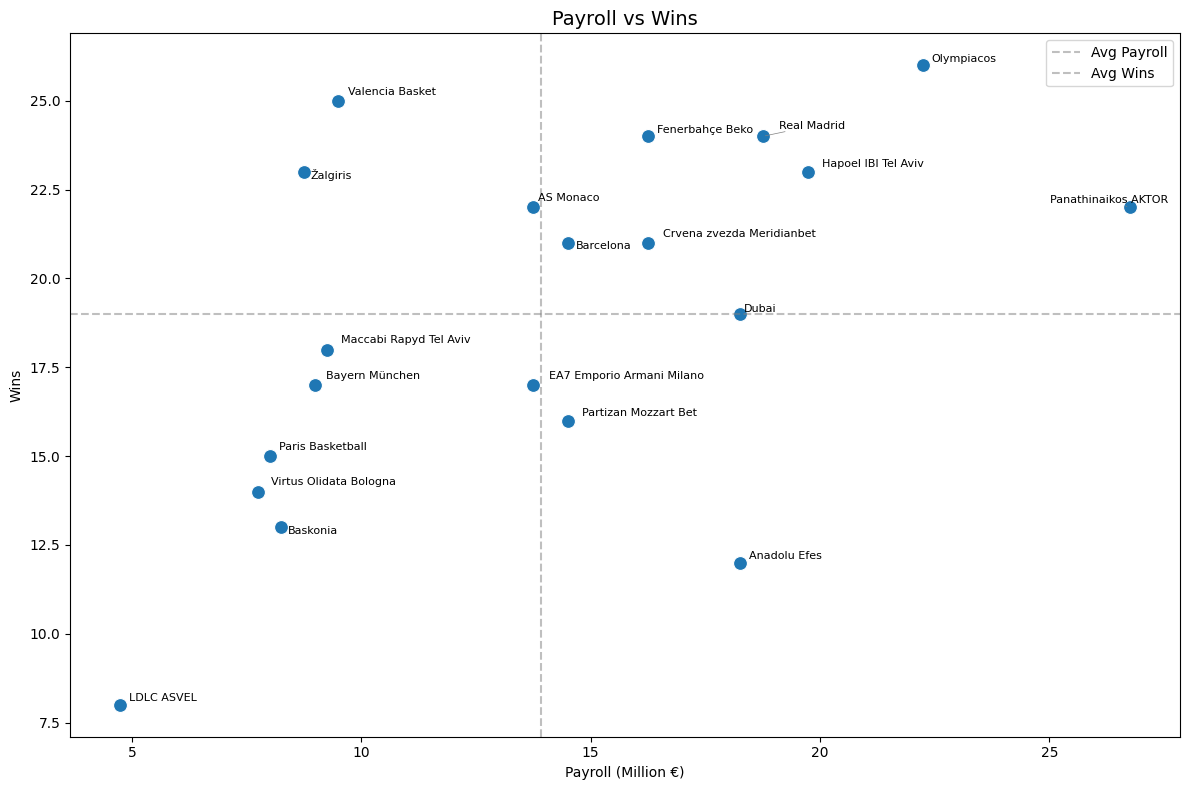

In [10]:
# Question 8: Does budget correlate with performance?
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_teams, x="payroll_M", y="W", s=100, ax=ax)
texts = []
for _, row in df_teams.iterrows():
    texts.append(ax.text(row["payroll_M"], row["W"], row["Team"], fontsize=8))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.axvline(df_teams["payroll_M"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg Payroll")
ax.axhline(df_teams["W"].mean(), color="gray", linestyle="--", alpha=0.5, label="Avg Wins")
ax.set_title("Payroll vs Wins", fontsize=14)
ax.set_xlabel("Payroll (Million €)")
ax.set_ylabel("Wins")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Export data for Power BI
df_teams.to_csv('../data/powerbi_teams.csv', index=False)
dependency.to_csv('../data/powerbi_dependency.csv', index=False)

# Player stats with additional columns for Power BI
players = player_stats.copy()
players['PTS_per_min'] = (players['PTS'] / players['MP']).round(4)
players['Non_Scoring_per_min'] = (
    (players['TRB'] + players['AST'] + players['STL'] + players['BLK'] - players['TOV'])
    / players['MP']
).round(4)
players['Underrated'] = (
    (players['PTS_per_min'] < 0.35) &
    (players['Non_Scoring_per_min'] > 0.30) &
    (players['MP'] > 200)
).map({True: 'Underrated', False: 'Other'})

players.to_csv('../data/powerbi_players.csv', index=False)
print('✅ CSV files exported for Power BI!')

✅ CSV files exported for Power BI!
